In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Load & Explore Data

In [2]:
df = pd.read_csv("data.csv", nrows=50000)
print("DATA TYPES")
print(df.dtypes)
print("\nDESCRIPTIVE STATISTICS")
print(df.describe())
print("\nMISSING VALUES")
print(df.isnull().sum())

DATA TYPES
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
dtype: object

DESCRIPTIVE STATISTICS
           VendorID  passenger_count  trip_distance    RatecodeID  \
count  50000.000000     50000.000000   50000.000000  50000.000000   
mean       1.695700         1.669820       2.986661      1.064380   
std        0.460115         1.195487       2.964573      1.236344   
min        1.000000         0.000000       0.000000      1.000000   
25%        1

## Data Cleaning

In [3]:
df.dropna(inplace=True)
print("DUPLICATES BEFORE:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("DUPLICATES AFTER:", df.duplicated().sum())

DUPLICATES BEFORE: 0
DUPLICATES AFTER: 0


## Feature Engineering

In [4]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month

df["trip_duration"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

## Outlier Removal

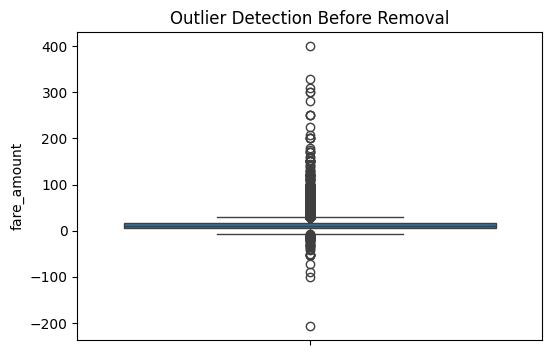

Number of Outliers: 2476


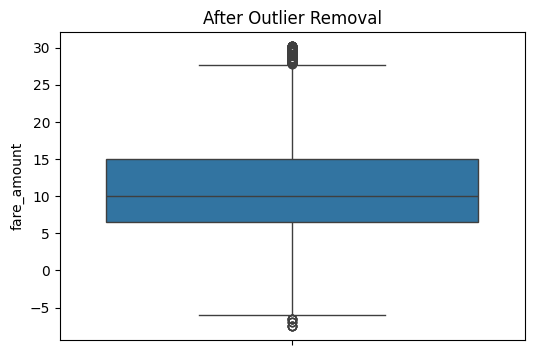

In [5]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["fare_amount"])
plt.title("Outlier Detection Before Removal")
plt.show()

Q1 = df["fare_amount"].quantile(0.25)
Q3 = df["fare_amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Number of Outliers:", len(df[(df["fare_amount"] < lower) | (df["fare_amount"] > upper)]))
df = df[(df["fare_amount"] >= lower) & (df["fare_amount"] <= upper)]

plt.figure(figsize=(6,4))
sns.boxplot(y=df["fare_amount"])
plt.title("After Outlier Removal")
plt.show()

## Visualizations

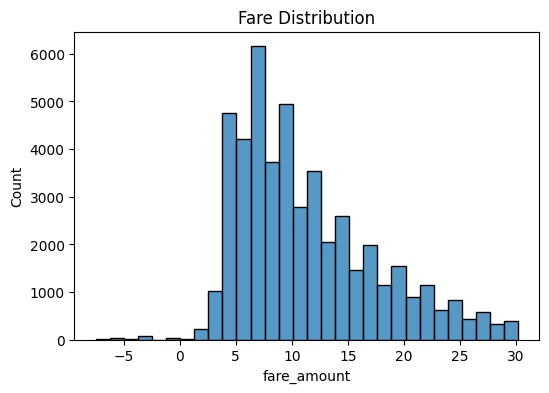

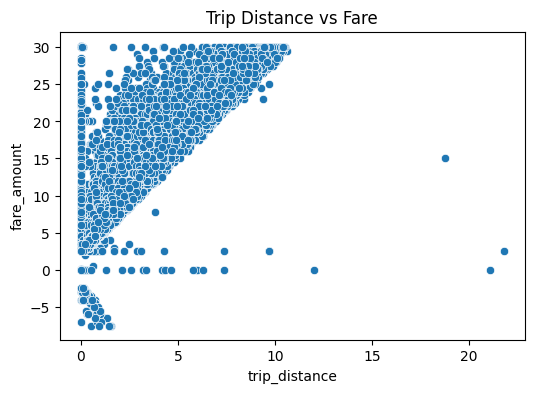

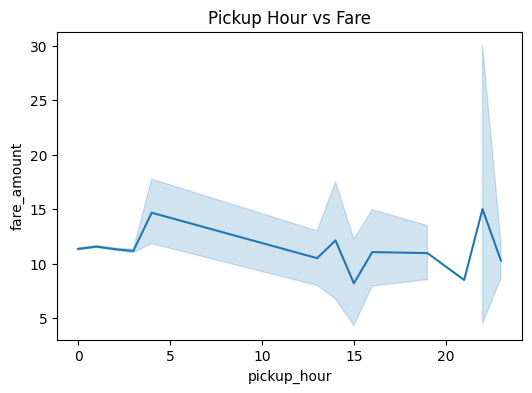

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df["fare_amount"], bins=30)
plt.title("Fare Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="trip_distance", y="fare_amount", data=df)
plt.title("Trip Distance vs Fare")
plt.show()

plt.figure(figsize=(6,4))
sns.lineplot(x="pickup_hour", y="fare_amount", data=df)
plt.title("Pickup Hour vs Fare")
plt.show()

## Model Training & Comparison

In [7]:
X = df[["trip_distance", "passenger_count", "pickup_hour", "pickup_day", "pickup_month", "trip_duration"]]
y = df["fare_amount"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)
pred_gb = gb.predict(X_test)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "R2 Score": [r2_score(y_test, pred_lr), r2_score(y_test, pred_rf), r2_score(y_test, pred_gb)],
    "MAE": [mean_absolute_error(y_test, pred_lr), mean_absolute_error(y_test, pred_rf), mean_absolute_error(y_test, pred_gb)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, pred_lr)), np.sqrt(mean_squared_error(y_test, pred_rf)), np.sqrt(mean_squared_error(y_test, pred_gb))]
})

print("MODEL COMPARISON")
print(results.sort_values(by="R2 Score", ascending=False))

MODEL COMPARISON
               Model  R2 Score       MAE      RMSE
2  Gradient Boosting  0.961330  0.423550  1.213053
1      Random Forest  0.955561  0.426957  1.300399
0  Linear Regression  0.869924  1.365954  2.224805
